In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

def list_images(class_name):
    img_dir = dataset_path / class_name / IMAGES_SUBDIR
    if not img_dir.exists():
        # fall back to flat structure: DATA_DIR/<class>/*.png
        img_dir = dataset_path / class_name
    return sorted([p for p in img_dir.glob("*.png")])


IMAGES_SUBDIR = "images"
MASKS_SUBDIR = "masks"
PCA_SIZE = (64, 64)
DATA_DIR = Path("../data/raw")
CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

class_files = {c: list_images(c) for c in CLASSES}

X = []
y = []


for c in CLASSES:
    for f in class_files[c]:
        try:
            with Image.open(f).convert("L") as im:
                im = im.resize(PCA_SIZE)

                arr = np.asarray(
                    im,
                    dtype=np.float32
                )

            # Flatten 64 × 64 image → 4096 features
            X.append(arr.flatten())
            y.append(c)

        except Exception as e:
            print(f"Could not read {f}: {e}")

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

In [ ]:
X = X / 255.0

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

In [ ]:
COLORS = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#1f77b4",
    "Viral Pneumonia": "#ff7f0e"
}

fig, ax = plt.subplots(figsize=(8, 6))

for c in CLASSES:
    mask = y == c

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.35,
        label=c,
        color=COLORS[c]
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("PCA of chest X-ray images by diagnostic class")

ax.legend(markerscale=2)
plt.savefig(
    "pca_xray_by_class.png",
    dpi=150,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)

print(
    "PC1 + PC2:",
    pca.explained_variance_ratio_.sum()
)

In [ ]:
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"PC1 + PC2: {pca.explained_variance_ratio_[:2].sum():.3f}")

In [ ]:
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

ax.set_xlabel(f"Principal Component 1 ({pc1_var:.1f}% variance)")
ax.set_ylabel(f"Principal Component 2 ({pc2_var:.1f}% variance)")

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(
        cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance: "
        f"{n_components} components"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")

plt.tight_layout()
plt.savefig(
    "pca_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

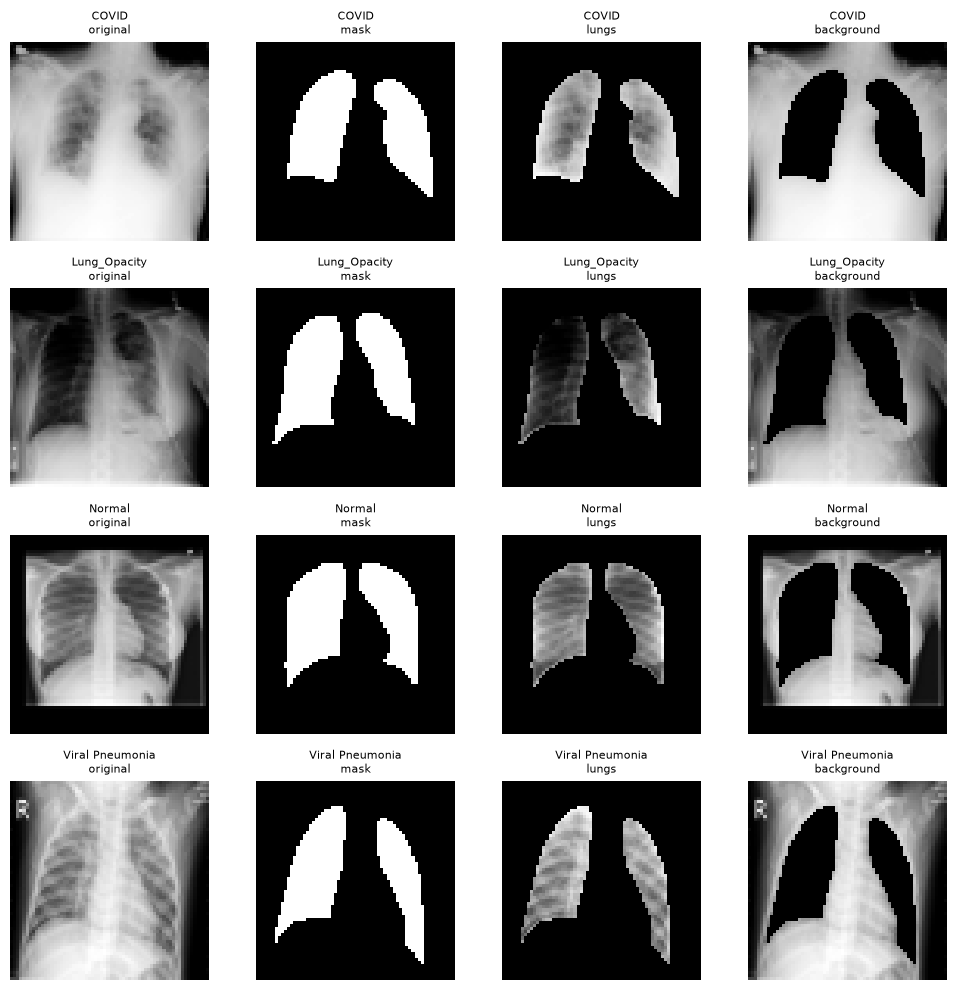

In [5]:
import matplotlib.pyplot as plt
from covid_xray.training import BaselineConfig, build_raw_manifest
from covid_xray.training.features import apply_region
from covid_xray.preprocessing.transforms import read_grayscale, resize_image, resize_mask
from covid_xray.config import CLASS_COLUMN, IMAGE_PATH_COLUMN, MASK_PATH_COLUMN

cfg = BaselineConfig()
manifest = build_raw_manifest(redundant_csv="../data/metadata/redundant_images.csv")

# One example per class, so you can also eyeball class-specific differences.
sample = manifest.groupby(CLASS_COLUMN).first().reset_index()

fig, axes = plt.subplots(len(sample), 4, figsize=(10, 2.5 * len(sample)))
for ax_row, (_, row) in zip(axes, sample.iterrows()):
    img = resize_image(read_grayscale(row[IMAGE_PATH_COLUMN]), cfg.image_size)
    msk = resize_mask(read_grayscale(row[MASK_PATH_COLUMN]), cfg.image_size)
    panels = [("original", img), ("mask", msk)] + [
        (r, apply_region(img, msk, r, cfg.mask_threshold)) for r in ("lungs", "background")
    ]
    for ax, (title, panel) in zip(ax_row, panels):
        ax.imshow(panel, cmap="gray")
        ax.set_title(f"{row[CLASS_COLUMN]}\n{title}", fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.savefig("../reports/baseline/mask_sanity_check.png", dpi=150)

In [3]:
import sys, subprocess
from pathlib import Path

# Find the repo root by walking up until we see pyproject.toml
root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent
print("repo root:", root)

print(subprocess.run([sys.executable, "-m", "pip", "install", "-e", str(root)],
                     capture_output=True, text=True).stdout[-2000:])

repo root: /Users/berfinaktas/Projects/covid_project_folders/jun26_bds_int_covid
Obtaining file:///Users/berfinaktas/Projects/covid_project_folders/jun26_bds_int_covid
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of covid-xray to determine which version is compatible with other requirements. This could take a while.



In [1]:
import sys; print(sys.version)
import covid_xray; print(covid_xray.__file__)

3.14.6 (main, Jun 10 2026, 10:03:53) [Clang 17.0.0 (clang-1700.6.4.2)]
/Users/berfinaktas/Projects/covid_project_folders/jun26_bds_int_covid/src/covid_xray/__init__.py
